# 04 — Figure 1: Foreign credit supply shock

**Ports**: `Code/MATLAB/Figures.m` lines 22–43.

**Inputs**: `../output/shock_path.npz` (from notebook 03), `../output/params.npz` (from notebook 02).

**Outputs**:
- `../output/deFerra2020_fig1_credit_supply.png` — regenerated figure (Python).
- After the user inspects and approves, this gets copied to `Figures/deFerra2020_fig1_credit_supply.png` (replacing the manually-cropped image currently in the repo). The new image is bit-for-bit reproducible from a clean clone.

## What the figure shows (paper Fig. 1)

Two paths for the supply of foreign credit $\bar B_t / Y$:
1. **Credit Expansion** (dashed). The economy receives a sustained AR(1)-in-differences expansion of foreign credit starting from the initial steady state with zero NFA, asymptoting to the long-run NFA target.
2. **Unexpected Contraction** (solid). At quarter 41, foreign credit unexpectedly contracts back to the calibrated NFA along a quartic deceleration.

## Imports + load inputs

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

OUTPUT_DIR = Path('..') / 'output'
shock = np.load(OUTPUT_DIR / 'shock_path.npz')
params_npz = np.load(OUTPUT_DIR / 'params.npz')

TT = int(shock['TT'])
shock_b_agg = shock['shock_b_agg']
new_shock_b_agg = shock['new_shock_b_agg']
shock_start_t = int(shock['shock_start_t'])      # MATLAB 1-indexed → 41
shock_start_idx0 = int(shock['shock_start_idx0'])  # 0-indexed → 40
y_ss = float(shock['y_ss'])

# Figure 1 normalises the credit-supply path by output at the *initial* steady
# state (b_agg_ss = 0), matching MATLAB's `aggregates_initial.y` (Figures.m).
# Phase C notebook 09 computes this and saves it as initial_ss.npz['y_initial']
# (= 2.982035; the calibrated y_ss = 3.0625 is ~2.7% higher because the
# no-foreign-credit initial SS has a lower K/Y). Load the exact value when the
# Phase-C output is present (it is committed, so this holds on a clean clone)
# and fall back to the y_ss proxy only if outputs were wiped.
_ini_path = OUTPUT_DIR / 'initial_ss.npz'
if _ini_path.exists():
    y_initial = float(np.load(_ini_path)['y_initial'])
    _y_src = 'initial SS, notebook 09'
else:
    y_initial = y_ss
    _y_src = 'y_ss proxy (run notebook 09 for the exact initial-SS y)'
print(f'TT                = {TT}')
print(f'shock_start_idx0  = {shock_start_idx0}')
print(f'y_initial         = {y_initial:.6f}  [{_y_src}]')

TT                = 200
shock_start_idx0  = 40
y_initial         = 2.982035  [initial SS, notebook 09]


## Plot Figure 1

Port of `Figures.m` lines 22–43. Y-axis transformation: shock paths are in absolute units (per-capita kEUR); divide by quarterly $y_{ss}$ and multiply by $-1/4$ to obtain a *positive* fraction of annual GDP (sign flip because $\bar B < 0$ means foreigners are net creditors, which displays as a positive credit expansion from the home-country perspective).

Saved: ../output/deFerra2020_fig1_credit_supply.png


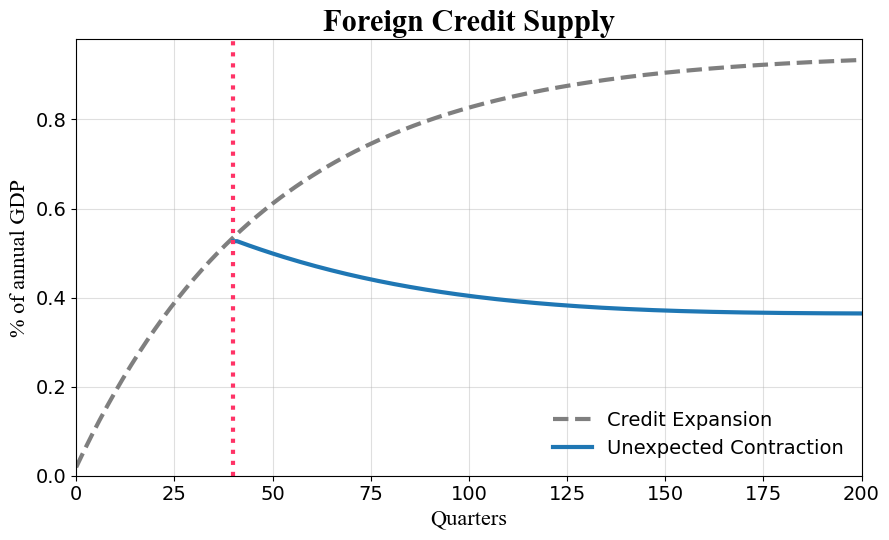

In [2]:
# Path 1 (credit expansion, dashed): MATLAB `plot(0:TT-1, ...)` → x = 0..TT-1
x_path1 = np.arange(TT)
y_path1 = -0.25 * shock_b_agg / y_initial

# Path 2 (unexpected contraction, solid): MATLAB
#   plot(shock_start_t-1:TT, -0.25*[shock_b_agg(shock_start_t-1); new_shock_b_agg(1:TT-shock_start_t+1)]/y)
# In MATLAB terms: x = 40..200 (length 161); first y is shock_b_agg(40), then new_shock_b_agg(1..160).
# In 0-indexed Python: x = shock_start_idx0..TT (i.e. 40..200, length 161); y is
# [shock_b_agg[shock_start_idx0 - 1], new_shock_b_agg[0..TT - shock_start_idx0 - 1]].
# Path 2 extends one quarter beyond Path 1's endpoint by MATLAB convention.
anchor_value = shock_b_agg[shock_start_idx0 - 1]
n_path2_after_anchor = TT - shock_start_idx0
x_path2 = np.arange(shock_start_idx0, TT + 1)
y_path2 = -0.25 * np.concatenate([[anchor_value], new_shock_b_agg[:n_path2_after_anchor]]) / y_initial

fig, ax = plt.subplots(figsize=(9, 5.5))

# Colours mimic MATLAB's lines(20) palette: orange for Path 1 (col_poss(1)),
# blue for Path 2 (col_poss(2))
color_expansion = '#7f7f7f'   # MATLAB lines(20)(6,:) — gray-tone
color_contraction = '#1f77b4'  # MATLAB lines(20)(1,:) — default blue
color_vertical = '#ff3366'     # MATLAB [1 .2 .4]

ax.plot(x_path1, y_path1, lw=3, color=color_expansion, ls='--', label='Credit Expansion')
ax.plot(x_path2, y_path2, lw=3, color=color_contraction, label='Unexpected Contraction')

ax.axvline(shock_start_idx0, color=color_vertical, lw=3, ls=':')

ax.set_xlabel('Quarters', fontname='Times New Roman', fontsize=16)
ax.set_ylabel('% of annual GDP', fontname='Times New Roman', fontsize=16)
ax.set_title('Foreign Credit Supply', fontname='Times New Roman', fontsize=22, fontweight='bold')
ax.tick_params(labelsize=14)
ax.grid(True, alpha=0.4)
ax.legend(loc='lower right', frameon=False, fontsize=14)
ax.set_xlim(0, TT)  # MATLAB `axis([0 TT-1 0 1])` — keep the [0, TT] window
ax.set_ylim(0, max(y_path1.max(), y_path2.max()) * 1.05)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)

plt.tight_layout()
fig_path = OUTPUT_DIR / 'deFerra2020_fig1_credit_supply.png'
fig.savefig(fig_path, dpi=200, bbox_inches='tight')
print(f'Saved: {fig_path}')
plt.show()

## Side-by-side comparison with the original paper image

Loads the existing `Figures/deFerra2020_fig1_credit_supply.png` (the manually-cropped paper image currently committed) and shows it next to the regenerated Python figure for visual validation.

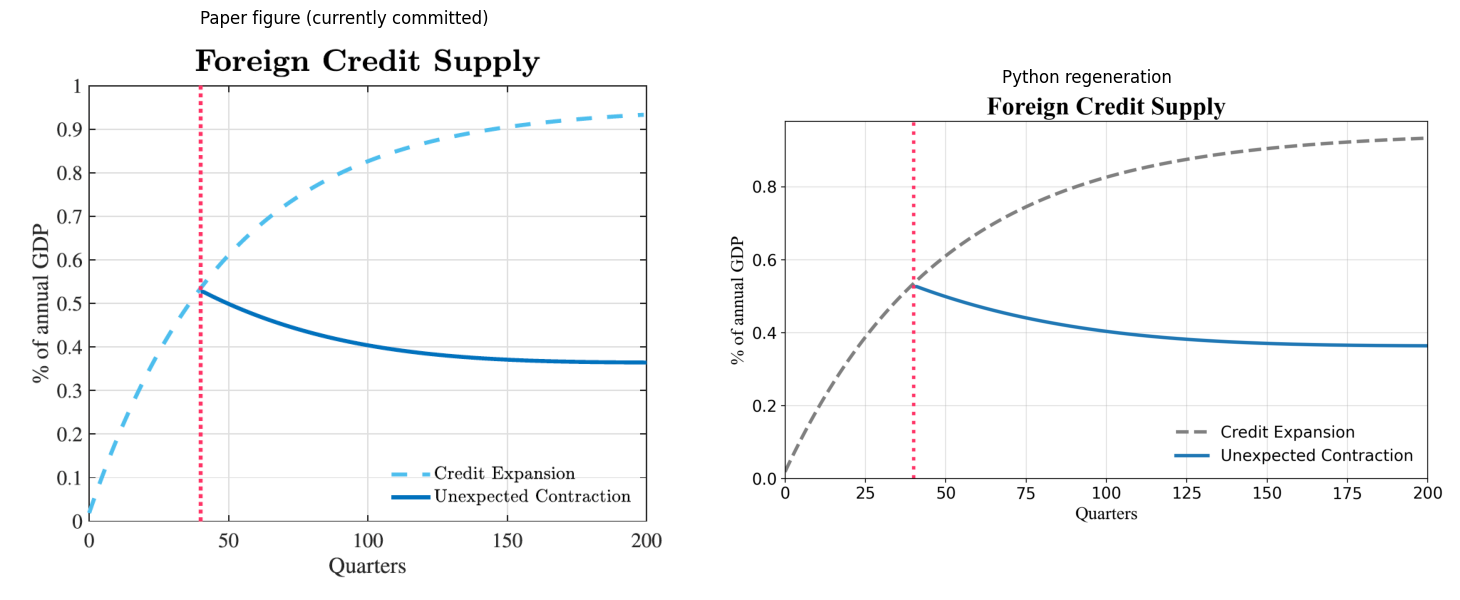

In [3]:
import matplotlib.image as mpimg

REPO_ROOT = Path('..').resolve().parent.parent  # Code/Python/notebooks/.. → repo root
paper_fig_path = REPO_ROOT / 'Figures' / 'deFerra2020_fig1_credit_supply.png'
python_fig_path = OUTPUT_DIR / 'deFerra2020_fig1_credit_supply.png'

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
if paper_fig_path.exists():
    axes[0].imshow(mpimg.imread(paper_fig_path))
    axes[0].set_title('Paper figure (currently committed)')
else:
    axes[0].text(0.5, 0.5, '(paper figure not found)', ha='center')
axes[0].axis('off')

axes[1].imshow(mpimg.imread(python_fig_path))
axes[1].set_title('Python regeneration')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Numerical sanity

Path 1 should peak around 0.5 (≈ 50% of annual GDP) per the paper's narrative; Path 2 should converge back to the calibrated NFA-to-quarterly-GDP ratio = `target.nfa_gdp` after the contraction.

In [4]:
print(f'Path 1 maximum  : {y_path1.max():.4f}  ({y_path1.max() * 100:.1f}% of annual GDP)')
print(f'Path 1 final    : {y_path1[-1]:.4f}')
print(f'Path 2 anchor   : {y_path2[0]:.4f}  (= Path 1 at t={shock_start_idx0 - 1})')
print(f'Path 2 final    : {y_path2[-1]:.4f}')

# Path 2 plots new_shock_b_agg[:160], so the last plotted value is new_shock_b_agg[159],
# which has not yet fully converged to BGss (full convergence is at index 199 with temp=0).
expected_last_plotted = -0.25 * float(new_shock_b_agg[n_path2_after_anchor - 1]) / y_initial
expected_BGss_norm = -0.25 * float(shock['BGss']) / y_initial
print(f'Expected last plotted          : {expected_last_plotted:.4f}')
print(f'Long-run target (-0.25*BGss/y) : {expected_BGss_norm:.4f}')
assert np.isclose(y_path2[-1], expected_last_plotted, atol=1e-12)

Path 1 maximum  : 0.9333  (93.3% of annual GDP)
Path 1 final    : 0.9333
Path 2 anchor   : 0.5266  (= Path 1 at t=39)
Path 2 final    : 0.3644
Expected last plotted          : 0.3644
Long-run target (-0.25*BGss/y) : 0.3641
